In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

air_data = pd.read_excel("/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Data/AirQuality.xlsx")
air_data

,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7.6,7.6,272,467,14.9,5.2,82,14
1,39.1,34.9,143,426,7.9,5.1,36,35
2,15.5,14.7,175,453,14.9,2.9,29,41
3,4.7,4.6,261,455,9.4,5.1,68,29
4,9.6,5.6,149,466,5.5,3.4,28,8
...,...,...,...,...,...,...,...,...
124995,156.6,154.8,696,449,10.8,16.3,139,201
124996,260.8,258.9,1201,532,23.2,16.7,131,201
124997,170.6,155.3,971,481,71.8,6.3,40,201
124998,107.2,113.1,1142,520,119.0,6.0,157,201


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PLOT_DIR = "/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Plots"
os.makedirs(PLOT_DIR, exist_ok=True)
DATAPREPROCESSING_DIR = "/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Data_Preprocessing"
os.makedirs(DATAPREPROCESSING_DIR, exist_ok=True)

# Data Prepocessing

In [ ]:
air_data.isnull().sum()

,0
pm10,0
pm2_5,0
carbon_monoxide,0
carbon_dioxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aqi,0


In [ ]:
air_data.shape

(125000, 8)

In [ ]:
air_data.dtypes

,0
pm10,float64
pm2_5,float64
carbon_monoxide,int64
carbon_dioxide,int64
nitrogen_dioxide,float64
sulphur_dioxide,float64
ozone,int64
aqi,int64


In [ ]:
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125000 entries, 0 to 124999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   pm10              125000 non-null  float64
 1   pm2_5             125000 non-null  float64
 2   carbon_monoxide   125000 non-null  int64  
 3   carbon_dioxide    125000 non-null  int64  
 4   nitrogen_dioxide  125000 non-null  float64
 5   sulphur_dioxide   125000 non-null  float64
 6   ozone             125000 non-null  int64  
 7   aqi               125000 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 7.6 MB


In [ ]:
air_data.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
pm10,125000.0,74.014626,66.312159,2.7,24.3,47.1,107.4,260.8
pm2_5,125000.0,69.119851,65.222654,2.5,21.4,41.5,100.4,258.9
carbon_monoxide,125000.0,523.962704,344.298257,120.0,260.0,391.0,718.0,3652.0
carbon_dioxide,125000.0,461.149216,24.680143,420.0,445.0,455.0,469.0,634.0
nitrogen_dioxide,125000.0,25.072681,30.550763,0.0,6.5,12.8,27.8,168.6
sulphur_dioxide,125000.0,9.415867,8.213567,0.1,3.4,6.3,12.9,54.1
ozone,125000.0,84.517568,49.923805,0.0,48.0,73.0,113.0,269.0
aqi,125000.0,117.809904,64.227252,6.0,60.0,123.0,171.0,255.0


# check Qutliers

In [ ]:
numeric_columns = air_data.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']


In [ ]:
outlier_summary = []

for column in numeric_columns:
    Q1 = air_data[column].quantile(0.25)
    Q3 = air_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (air_data[column] < lower_bound) |
        (air_data[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,pm10,24.3,107.4,83.1,-100.35,232.05,4954
1,pm2_5,21.4,100.4,79.0,-97.10,218.90,6060
2,carbon_monoxide,260.0,718.0,458.0,-427.00,1405.00,1806
3,carbon_dioxide,445.0,469.0,24.0,409.00,505.00,10077
4,nitrogen_dioxide,6.5,27.8,21.3,-25.45,59.75,16094
5,sulphur_dioxide,3.4,12.9,9.5,-10.85,27.15,6959
6,ozone,48.0,113.0,65.0,-49.50,210.50,2128
7,aqi,60.0,171.0,111.0,-106.50,337.50,0


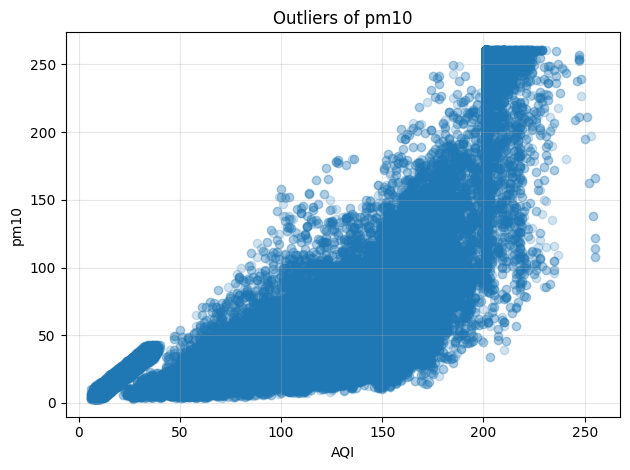

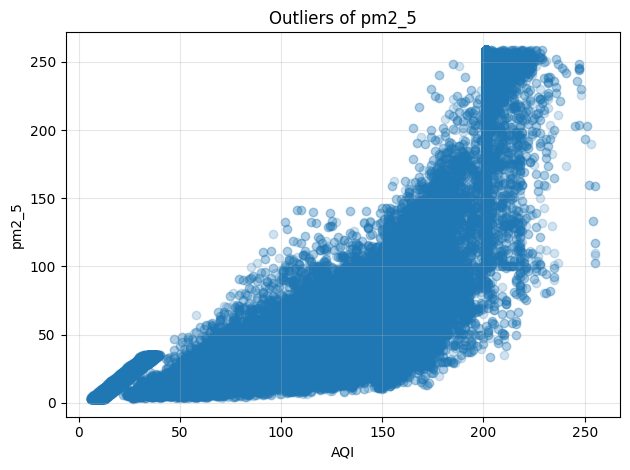

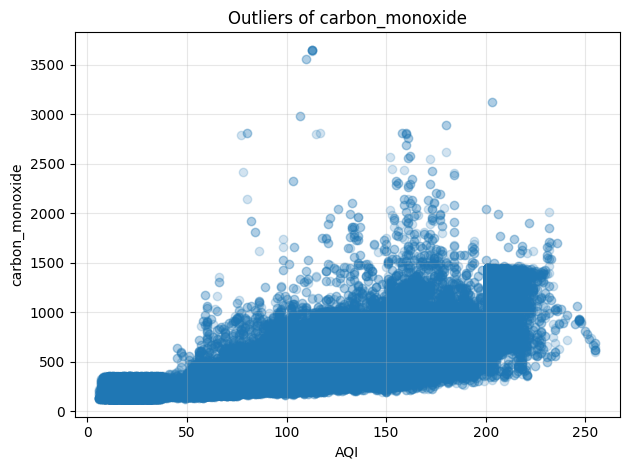

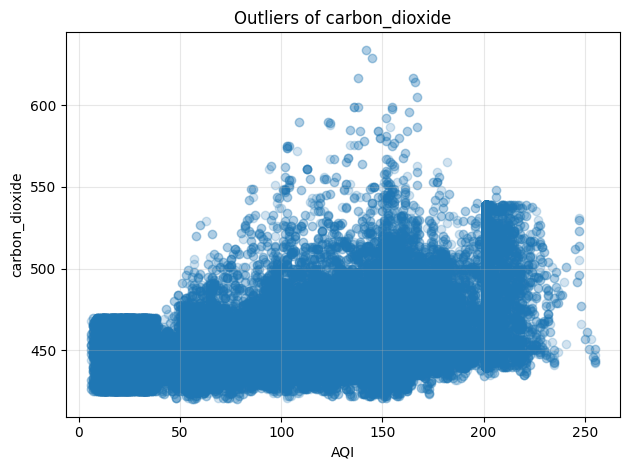

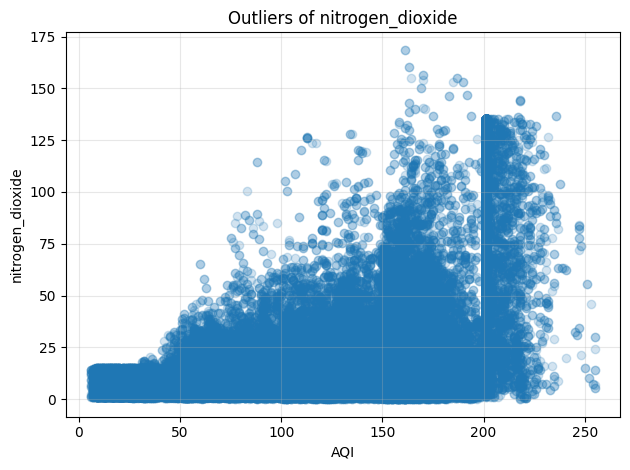

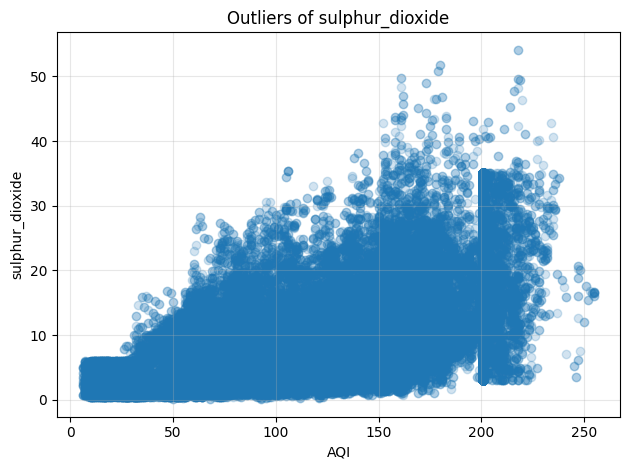

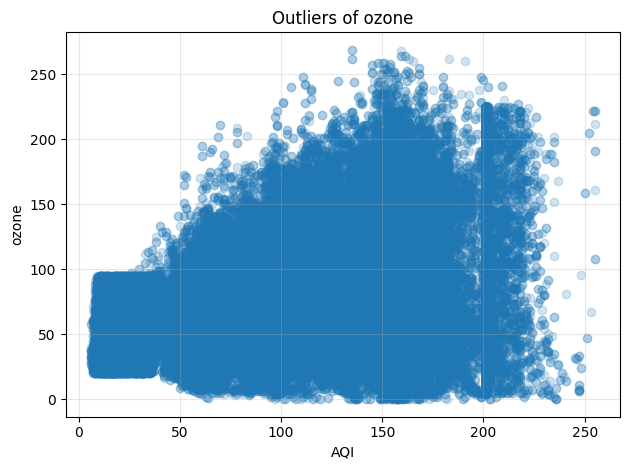

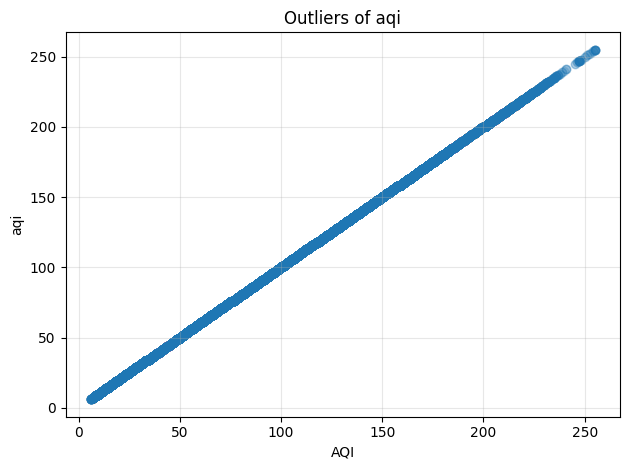

<Figure size 640x480 with 0 Axes>

In [ ]:
for column in numeric_columns:


    plt.scatter(
        air_data["aqi"],
        air_data[column],
        alpha=0.2
    )

    plt.title(f"Outliers of {column}")
    plt.xlabel("AQI")
    plt.ylabel(column)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.savefig(
        os.path.join(PLOT_DIR, f"outliers of {column}.png"),
        dpi = 300,
        bbox_inches = "tight"
        )


# check the target distribution

In [ ]:
print("Columns:")
print(air_data.columns.tolist())

Columns:
['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']


In [ ]:
print("\nAQI unique values:")
print(air_data["aqi"].nunique())

print("\nFirst 20 AQI values:")
print(air_data["aqi"].head(20).tolist())


AQI unique values:
246

First 20 AQI values:
[14, 35, 41, 29, 8, 16, 15, 26, 26, 33, 14, 49, 13, 26, 26, 31, 33, 12, 23, 34]


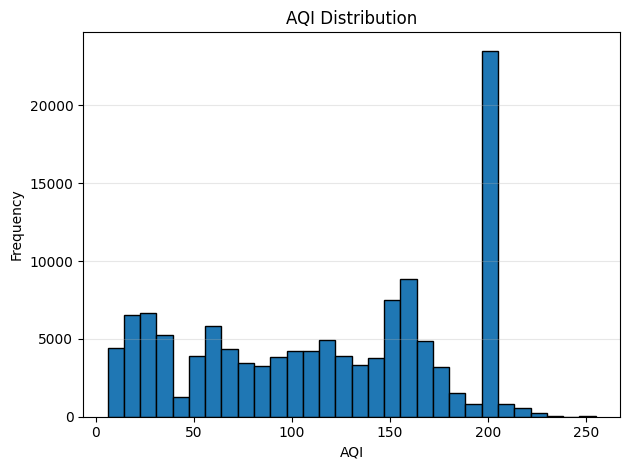

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.hist(
    air_data["aqi"],
    bins=30,
    edgecolor="black"
)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig(
    os.path.join(PLOT_DIR, "aqi_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

# Create AQI Category

In [ ]:
def classify_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"


air_data["air_quality_category"] = air_data["aqi"].apply(classify_aqi)

air_data

,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi,air_quality_category
0,7.6,7.6,272,467,14.9,5.2,82,14,Good
1,39.1,34.9,143,426,7.9,5.1,36,35,Good
2,15.5,14.7,175,453,14.9,2.9,29,41,Good
3,4.7,4.6,261,455,9.4,5.1,68,29,Good
4,9.6,5.6,149,466,5.5,3.4,28,8,Good
...,...,...,...,...,...,...,...,...,...
124995,156.6,154.8,696,449,10.8,16.3,139,201,Very Unhealthy
124996,260.8,258.9,1201,532,23.2,16.7,131,201,Very Unhealthy
124997,170.6,155.3,971,481,71.8,6.3,40,201,Very Unhealthy
124998,107.2,113.1,1142,520,119.0,6.0,157,201,Very Unhealthy


In [ ]:
print(air_data["air_quality_category"].value_counts())

air_quality_category
Good                              25000
Moderate                          25000
Unhealthy                         25000
Unhealthy for Sensitive Groups    25000
Very Unhealthy                    25000
Name: count, dtype: int64


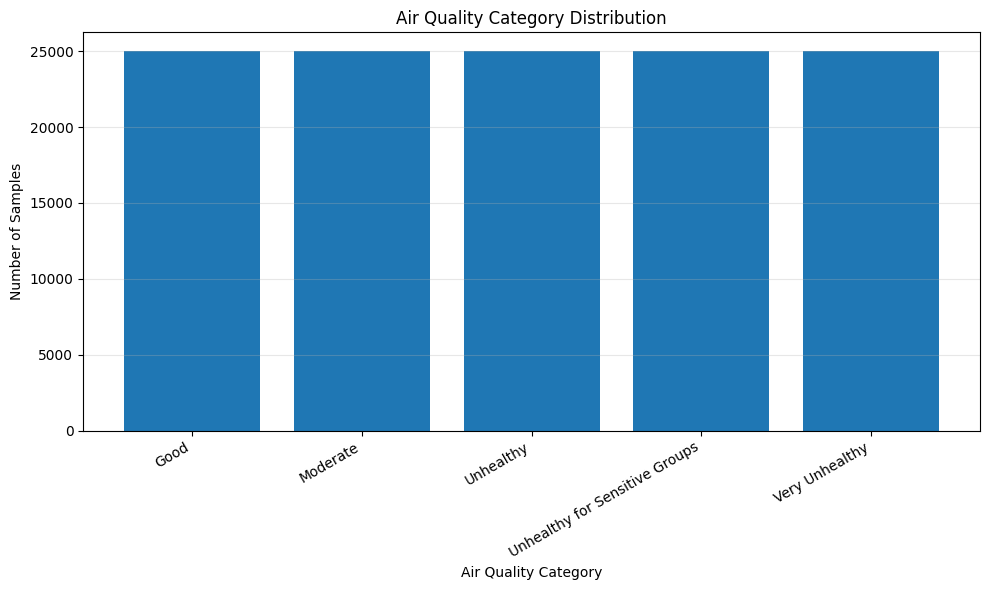

<Figure size 640x480 with 0 Axes>

In [ ]:
class_counts = air_data["air_quality_category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Air Quality Category Distribution")
plt.xlabel("Air Quality Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig(
    os.path.join(PLOT_DIR, "air_quality_category_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

# Separate X and y

In [ ]:
feature_columns = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "carbon_dioxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

X = air_data[feature_columns].copy()

y = air_data["air_quality_category"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (125000, 7)
y shape: (125000,)

Features:
['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']

Target:
air_quality_category


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (100000, 7)
X_test: (25000, 7)
y_train: (100000,)
y_test: (25000,)


In [ ]:
X_train.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "X_train.csv"),
    index=False
)
X_test.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "X_test.csv"),
    index=False
)
y_train.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "y_train.csv"),
    index=False
)
y_test.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "y_test.csv"),
    index=False
)

In [ ]:
print("Training classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training classes:
air_quality_category
Unhealthy                         20000
Unhealthy for Sensitive Groups    20000
Moderate                          20000
Very Unhealthy                    20000
Good                              20000
Name: count, dtype: int64

Testing classes:
air_quality_category
Unhealthy                         5000
Moderate                          5000
Unhealthy for Sensitive Groups    5000
Very Unhealthy                    5000
Good                              5000
Name: count, dtype: int64


# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:")
print(label_encoder.classes_)

Classes:
['Good' 'Moderate' 'Unhealthy' 'Unhealthy for Sensitive Groups'
 'Very Unhealthy']


In [ ]:
for class_name, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"{class_name} -> {encoded_value}")

Good -> 0
Moderate -> 1
Unhealthy -> 2
Unhealthy for Sensitive Groups -> 3
Very Unhealthy -> 4


In [ ]:
print("Training class distribution:")
print(pd.Series(y_train_encoded).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test_encoded).value_counts().sort_index())

Training class distribution:
0    20000
1    20000
2    20000
3    20000
4    20000
Name: count, dtype: int64

Testing class distribution:
0    5000
1    5000
2    5000
3    5000
4    5000
Name: count, dtype: int64


In [ ]:
MODELS_DIR = "/content/drive/MyDrive/Air_Quality/Model"

os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(
    label_encoder,
    os.path.join(MODELS_DIR, "label_encoder.pkl")
)

print("✓ label_encoder.pkl saved")

✓ label_encoder.pkl saved


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (100000, 7)
X_test_scaled shape: (25000, 7)


In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

X_train_scaled.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "X_train_scaled.csv"),
    index=False
)
X_test_scaled.to_csv(
    os.path.join(DATAPREPROCESSING_DIR, "X_test_scaled.csv"),
    index=False
)

,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone
39922,-0.251553,-0.331219,-0.559953,-0.572063,-0.784651,0.585435,2.428705
54461,-0.560930,-0.507674,-0.365647,-0.572063,-0.398410,-0.646400,0.068030
90325,-0.782775,-0.737833,-0.371448,0.035992,0.079481,1.000113,-1.452405
64656,1.631870,1.640478,2.024017,3.360028,-0.238022,1.353808,-0.172039
43980,-0.041781,0.026295,-0.229344,-0.004545,0.707941,0.987916,-1.152319


In [ ]:
feature_names = pd.DataFrame({
    "feature_name": X_train.columns
})

feature_names.to_csv(
    os.path.join(MODELS_DIR, "feature_names.csv"),
    index=False
)

print("✓ feature_names.csv saved")

joblib.dump(
    scaler,
    os.path.join(MODELS_DIR, "scaler.pkl")
)

print("✓ scaler.pkl saved")


✓ feature_names.csv saved
✓ scaler.pkl saved


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_Model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_Model.fit(
    X_train_scaled,
    y_train_encoded
)

y_pred_logistic = logistic_Model.predict(
    X_test_scaled
)

print("✓ Logistic Regression trained")

✓ Logistic Regression trained


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

logistic_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_logistic
)

logistic_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_logistic,
    average="macro"
)

logistic_weighted_f1 = f1_score(
    y_test_encoded,
    y_pred_logistic,
    average="weighted"
)

print("Logistic Regression Results")

print("Accuracy     :", round(logistic_accuracy, 4))
print("Macro F1     :", round(logistic_macro_f1, 4))
print("Weighted F1  :", round(logistic_weighted_f1, 4))

Logistic Regression Results
Accuracy     : 0.6894
Macro F1     : 0.6878
Weighted F1  : 0.6878


In [ ]:
from sklearn.metrics import classification_report

logistic_report = classification_report(
    y_test_encoded,
    y_pred_logistic,
    target_names=label_encoder.classes_
)

print(logistic_report)

                                precision    recall  f1-score   support

                          Good       0.65      0.73      0.69      5000
                      Moderate       0.51      0.45      0.48      5000
                     Unhealthy       0.73      0.72      0.72      5000
Unhealthy for Sensitive Groups       0.61      0.62      0.62      5000
                Very Unhealthy       0.94      0.92      0.93      5000

                      accuracy                           0.69     25000
                     macro avg       0.69      0.69      0.69     25000
                  weighted avg       0.69      0.69      0.69     25000



In [ ]:
joblib.dump(
    logistic_Model,
    os.path.join(MODELS_DIR, "logistic_regression.pkl")
)


['/content/drive/MyDrive/Air_Quality/Model/logistic_regression.pkl']

# Test with new unseen data

In [ ]:
model = joblib.load("/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Model/logistic_regression.pkl")
scaler = joblib.load("/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Model/scaler.pkl")
encoder = joblib.load("/content/drive/MyDrive/Machine Learning/Air_Quality-20260825T165738Z-1-001/Air_Quality/Model/label_encoder.pkl")

new_data = pd.DataFrame([{
    "pm10": 10,
    "pm2_5": 20,
    "carbon_monoxide": 15,
    "carbon_dioxide": 10,
    "nitrogen_dioxide": 10,
    "sulphur_dioxide": 9,
    "ozone": 10
}])

prediction = model.predict(scaler.transform(new_data))

print("Predicted Air Quality:",
      encoder.inverse_transform(prediction)[0])

Predicted Air Quality: Good


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train_encoded
)

print("✓ Decision Tree trained successfully")

✓ Decision Tree trained successfully


In [ ]:
y_pred_dt = decision_tree_model.predict(X_test)

print("✓ Predictions generated")

✓ Predictions generated


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

dt_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_dt
)

dt_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_dt,
    average="macro"
)

dt_weighted_f1 = f1_score(
    y_test_encoded,
    y_pred_dt,
    average="weighted"
)

print("Decision Tree Results")
print("=" * 30)
print("Accuracy    :", round(dt_accuracy, 4))
print("Macro F1    :", round(dt_macro_f1, 4))
print("Weighted F1 :", round(dt_weighted_f1, 4))

Decision Tree Results
Accuracy    : 0.9213
Macro F1    : 0.9214
Weighted F1 : 0.9214


In [ ]:
from sklearn.metrics import classification_report

dt_report = classification_report(
    y_test_encoded,
    y_pred_dt,
    target_names=label_encoder.classes_
)

print(dt_report)

                                precision    recall  f1-score   support

                          Good       0.94      0.94      0.94      5000
                      Moderate       0.89      0.88      0.88      5000
                     Unhealthy       0.93      0.90      0.91      5000
Unhealthy for Sensitive Groups       0.87      0.90      0.89      5000
                Very Unhealthy       0.98      0.98      0.98      5000

                      accuracy                           0.92     25000
                     macro avg       0.92      0.92      0.92     25000
                  weighted avg       0.92      0.92      0.92     25000



In [ ]:
joblib.dump(
    decision_tree_model,
    os.path.join(MODELS_DIR, "decision_tree.pkl")
)

print("✓ decision_tree.pkl saved")

✓ decision_tree.pkl saved


In [ ]:
new_data = pd.DataFrame([{
    "pm10": 201,
    "pm2_5": 15,
    "carbon_monoxide": 20,
    "carbon_dioxide": 40,
    "nitrogen_dioxide": 5,
    "sulphur_dioxide": 2,
    "ozone": 40
}])

prediction = decision_tree_model.predict(new_data)

print("Predicted Air Quality:",
      label_encoder.inverse_transform(prediction)[0])

Predicted Air Quality: Good


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train_encoded
)

print("✓ Random Forest trained successfully")

✓ Random Forest trained successfully


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

rf_accuracy = accuracy_score(y_test_encoded, y_pred_rf)
rf_macro_f1 = f1_score(y_test_encoded, y_pred_rf, average="macro")

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro F1:", round(rf_macro_f1, 4))

Random Forest Accuracy: 0.9492
Random Forest Macro F1: 0.9492


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred_rf,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

                          Good       0.95      0.96      0.96      5000
                      Moderate       0.94      0.91      0.92      5000
                     Unhealthy       0.96      0.94      0.95      5000
Unhealthy for Sensitive Groups       0.91      0.95      0.93      5000
                Very Unhealthy       0.99      0.99      0.99      5000

                      accuracy                           0.95     25000
                     macro avg       0.95      0.95      0.95     25000
                  weighted avg       0.95      0.95      0.95     25000



In [ ]:
joblib.dump(
    random_forest_model,
    os.path.join(MODELS_DIR, "random_forest.pkl")
)

print("✓ random_forest.pkl saved")

✓ random_forest.pkl saved


In [ ]:
new_data = pd.DataFrame([{
    "pm10": 2.25,
    "pm2_5": 0.25,
    "carbon_monoxide": 20,
    "carbon_dioxide": 40,
    "nitrogen_dioxide": 5.25,
    "sulphur_dioxide": 2.0,
    "ozone": 40
}])

prediction = random_forest_model.predict(new_data)

print("Predicted Air Quality:",
      label_encoder.inverse_transform(prediction)[0])

Predicted Air Quality: Good


# Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(
    X_train,
    y_train_encoded
)

print("✓ Extra Trees trained successfully")

✓ Extra Trees trained successfully


In [ ]:
y_pred_et = extra_trees_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

et_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_et
)

et_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_et,
    average="macro"
)

print("Extra Trees Accuracy:", round(et_accuracy, 4))
print("Extra Trees Macro F1:", round(et_macro_f1, 4))

Extra Trees Accuracy: 0.9529
Extra Trees Macro F1: 0.9529


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred_et,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

                          Good       0.95      0.97      0.96      5000
                      Moderate       0.94      0.91      0.93      5000
                     Unhealthy       0.96      0.94      0.95      5000
Unhealthy for Sensitive Groups       0.92      0.96      0.94      5000
                Very Unhealthy       0.99      0.99      0.99      5000

                      accuracy                           0.95     25000
                     macro avg       0.95      0.95      0.95     25000
                  weighted avg       0.95      0.95      0.95     25000



In [ ]:
joblib.dump(
    extra_trees_model,
    os.path.join(MODELS_DIR, "extra_trees.pkl")
)

print("✓ extra_trees.pkl saved")

✓ extra_trees.pkl saved


In [ ]:
new_data = pd.DataFrame([{
    "pm10": 2.25,
    "pm2_5": 0.25,
    "carbon_monoxide": 20,
    "carbon_dioxide": 40,
    "nitrogen_dioxide": 5.25,
    "sulphur_dioxide": 2.0,
    "ozone": 40
}])

prediction = extra_trees_model.predict(new_data)

print(
    "Predicted Air Quality:",
    label_encoder.inverse_transform(prediction)[0]
)

Predicted Air Quality: Good


# Suport Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("✓ SVM (RBF) trained successfully")

✓ SVM (RBF) trained successfully


In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_svm

array([2, 0, 3, ..., 3, 3, 3])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

svm_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_svm
)

svm_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_svm,
    average="macro"
)

print("SVM Accuracy:", round(svm_accuracy, 4))
print("SVM Macro F1:", round(svm_macro_f1, 4))

SVM Accuracy: 0.762
SVM Macro F1: 0.7587


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred_svm,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

                          Good       0.73      0.87      0.79      5000
                      Moderate       0.69      0.52      0.59      5000
                     Unhealthy       0.79      0.76      0.78      5000
Unhealthy for Sensitive Groups       0.63      0.70      0.67      5000
                Very Unhealthy       0.97      0.96      0.97      5000

                      accuracy                           0.76     25000
                     macro avg       0.76      0.76      0.76     25000
                  weighted avg       0.76      0.76      0.76     25000



In [ ]:
joblib.dump(
    svm_model,
    os.path.join(MODELS_DIR, "svm.pkl")
)

print("✓ svm.pkl saved")

✓ svm.pkl saved


In [ ]:
new_data = pd.DataFrame([{
    "pm10": 2.25,
    "pm2_5": 1.5,
    "carbon_monoxide": 200,
    "carbon_dioxide": 440,
    "nitrogen_dioxide": 50.0,
    "sulphur_dioxide": 2.5,
    "ozone": 40
}])

prediction = svm_model.predict(
    scaler.transform(new_data)
)

print(
    "Predicted Air Quality:",
    label_encoder.inverse_transform(prediction)[0]
)

Predicted Air Quality: Moderate


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


# K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train_encoded
)

print("✓ KNN trained successfully")

✓ KNN trained successfully


In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

knn_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn
)

knn_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_knn,
    average="macro"
)

print("KNN Accuracy:", round(knn_accuracy, 4))
print("KNN Macro F1:", round(knn_macro_f1, 4))

KNN Accuracy: 0.8562
KNN Macro F1: 0.8569


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred_knn,
    target_names=label_encoder.classes_
))

                                precision    recall  f1-score   support

                          Good       0.89      0.86      0.87      5000
                      Moderate       0.77      0.79      0.78      5000
                     Unhealthy       0.86      0.85      0.85      5000
Unhealthy for Sensitive Groups       0.78      0.83      0.81      5000
                Very Unhealthy       0.99      0.96      0.97      5000

                      accuracy                           0.86     25000
                     macro avg       0.86      0.86      0.86     25000
                  weighted avg       0.86      0.86      0.86     25000



In [ ]:
joblib.dump(
    knn_model,
    os.path.join(MODELS_DIR, "knn.pkl")
)

print("✓ knn.pkl saved")

✓ knn.pkl saved


In [ ]:
new_data = pd.DataFrame([{
    "pm10": 85.20,
    "pm2_5": 15.5,
    "carbon_monoxide": 20,
    "carbon_dioxide": 440,
    "nitrogen_dioxide": 5.85,
    "sulphur_dioxide": 50.2,
    "ozone": 100
}])

prediction = knn_model.predict(
    scaler.transform(new_data)
)

print(
    "Predicted Air Quality:",
    label_encoder.inverse_transform(prediction)[0]
)

Predicted Air Quality: Unhealthy


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models_results = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Extra Trees": y_pred_et,
    "SVM (RBF)": y_pred_svm,
    "K-Nearest Neighbors": y_pred_knn
}

results = []

for model_name, predictions in models_results.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_encoded, predictions),
        "Precision": precision_score(
            y_test_encoded,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_encoded,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test_encoded,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            y_test_encoded,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

model_comparison = pd.DataFrame(results)

model_comparison = model_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Extra Trees,0.95292,0.953222,0.95292,0.952879,0.952879
1,Random Forest,0.94920,0.949526,0.94920,0.949168,0.949168
2,Decision Tree,0.92132,0.921606,0.92132,0.921383,0.921383
3,K-Nearest Neighbors,0.85616,0.858127,0.85616,0.856910,0.856910
4,SVM (RBF),0.76204,0.763728,0.76204,0.758672,0.758672
5,Logistic Regression,0.68936,0.687770,0.68936,0.687757,0.687757
